<a href="https://colab.research.google.com/github/Sriharikrishnan-TS/Portfolio_Projects/blob/main/EMNIST_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EMNIST CLASSIFICATION**

**importing necessary libraries**

In [ ]:
import torch
from torch.utils.data import DataLoader,random_split,ConcatDataset,Dataset
from torchvision import datasets, transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn as nn
import pickle
import pandas as pd
import numpy as np
import random

In [ ]:
# Set device for training (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


**Mount google drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Setting paths
train_csv_path = '/content/drive/My Drive/EMNIST/emnist-balanced-train.csv'
test_csv_path  = '/content/drive/My Drive/EMNIST/emnist-balanced-test.csv'
mapping_path = '/content/drive/My Drive/EMNIST/emnist-balanced-mapping.txt'

Mounted at /content/drive


Label Mapping

In [ ]:
label_to_char = {}
with open(mapping_path, 'r') as f:
    for line in f:
        label, ascii_code = map(int, line.strip().split())
        label_to_char[label] = chr(ascii_code)

print("EMNIST Balanced Class Mapping:")
for label in sorted(label_to_char):
    print(f"Label {label:2d}: {label_to_char[label]}")

EMNIST Balanced Class Mapping:
Label  0: 0
Label  1: 1
Label  2: 2
Label  3: 3
Label  4: 4
Label  5: 5
Label  6: 6
Label  7: 7
Label  8: 8
Label  9: 9
Label 10: A
Label 11: B
Label 12: C
Label 13: D
Label 14: E
Label 15: F
Label 16: G
Label 17: H
Label 18: I
Label 19: J
Label 20: K
Label 21: L
Label 22: M
Label 23: N
Label 24: O
Label 25: P
Label 26: Q
Label 27: R
Label 28: S
Label 29: T
Label 30: U
Label 31: V
Label 32: W
Label 33: X
Label 34: Y
Label 35: Z
Label 36: a
Label 37: b
Label 38: d
Label 39: e
Label 40: f
Label 41: g
Label 42: h
Label 43: n
Label 44: q
Label 45: r
Label 46: t


**CUSTOM DATASET CLASS WITH PROPER TRANSFORMS**

In [ ]:
class EMNISTCSV(Dataset):
    def __init__(self, csv_path, transform=None):
        df = pd.read_csv(csv_path)
        self.labels = df.iloc[:, 0].values.astype(np.int64)
        self.images = df.iloc[:, 1:].values.astype(np.uint8)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # EMNIST-specific rotation and flip correction
        img = self.images[idx].reshape(28, 28).T  # Transpose
        img = Image.fromarray(img, mode='L').rotate(-90).transpose(Image.FLIP_LEFT_RIGHT)

        if self.transform:
            img = self.transform(img)

        label = self.labels[idx]
        return img, label

**loading and preprocessing**

In [ ]:
from PIL import Image
train_transform =transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0,translate=(0.1,0.1)),
    transforms.Normalize((0.1307,), (0.3081,))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

**initializing hyperparameters**

In [ ]:
BATCH_SIZE = 256
LEARNING_RATE = 0.001
NUM_EPOCHS = 15
TRAIN_SPLIT = 0.85
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

**DOWNLOADING DATASET**

In [ ]:
full_train_data = EMNISTCSV(train_csv_path, transform=train_transform)
test_dataset = EMNISTCSV(test_csv_path, transform=test_transform)

**Splitting training dataset into train and validation,
test dataset is already ready**

In [ ]:
train_size = int(TRAIN_SPLIT * len(full_train_data))
val_size = len(full_train_data) - train_size
train_dataset, val_dataset = random_split(full_train_data, [train_size, val_size])

print(f"Dataset sizes - Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Dataset sizes - Train: 95879, Val: 16920, Test: 18799


**Create DataLoaders**

In [ ]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2,pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

**Build our model**

In [ ]:
import torch
import torch.nn as nn

class EMNISTModel(nn.Module):

    def __init__(self, num_classes=47):  # 47 for EMNIST Balanced, 10 as per diagram
        super(EMNISTModel, self).__init__()

        # Input layer (implicitly defined - 28x28 images)

        # Flatten layer: (None, 28, 28) -> (None, 784)
        self.flatten = nn.Flatten()

        # First hidden layer: (None, 784) -> (None, 16)
        self.fc1_block = nn.Sequential(
            nn.Linear(28 * 28, 16),  # this is the hidden layer
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2)  # dropout is a regularization technique(not necessary)
        )

        # Branch 1: Left branch with skip connection
        self.branch1_block1 = nn.Sequential(
            nn.Linear(16, 8),    # (None, 16) -> (None, 8)
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Dropout(0.2)  # dropout is applied in between the 2 hidden layers
        )
        self.branch1_block2 = nn.Sequential(
            nn.Linear(8, 8),     # (None, 8) -> (None, 8)
            nn.BatchNorm1d(8),
            nn.ReLU()
        )

        # Branch 2: Right branch
        self.branch2_block1 = nn.Sequential(
            nn.Linear(16, 12),   # (None, 16) -> (None, 12)
            nn.BatchNorm1d(12),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.branch2_block2 = nn.Sequential(
            nn.Linear(12, 8),    # (None, 12) -> (None, 8)
            nn.BatchNorm1d(8),
            nn.ReLU()
        )

        # Output layer: (None, 16) -> (None, num_classes)
        # Note: 16 comes from concatenation of two 8-dimensional vectors
        self.output = nn.Linear(16, num_classes)

    def forward(self, x):

        # Forward pass through the network

        # Flatten input: (batch_size, 28, 28) -> (batch_size, 784)
        x = self.flatten(x)

        # First hidden layer with ReLU activation
        x = self.fc1_block(x)

        # Branch 1: Left branch with skip connection
        b1 = self.branch1_block1(x)
        b1_output = self.branch1_block2(b1)

        # Skip connection: Add input and output of second layer in branch 1
        b1_skip = b1_output + b1  # Element-wise addition (skip connection)

        # Branch 2: Right branch
        b2 = self.branch2_block1(x)
        b2_output = self.branch2_block2(b2)

        # Concatenate outputs from both branches: (None, 8) + (None, 8) -> (None, 16)
        concat = torch.cat((b1_skip, b2_output), dim=1)

        # Final output layer
        output = self.output(concat)

        return output


**Initialize the model**

In [ ]:
model = EMNISTModel(num_classes=47).to(device)

**Loss and optimizer functions**

In [ ]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9,weight_decay=1e-4)
#weight decay refers to L2regularization
#we give a sort of penalty to the weights when they are larger by adding a extra term to the cost fucntion

**Scheduler**

In [ ]:
# Learning rate scheduler
#It monitors a validation metric (usually loss), and if that metric stops improving
#it reduces the learning rate automatically.
scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=5,gamma=0.5
)

**Print the model architecture**

In [ ]:
print("\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Model Architecture:
EMNISTModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1_block): Sequential(
    (0): Linear(in_features=784, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (branch1_block1): Sequential(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (branch1_block2): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (branch2_block1): Sequential(
    (0): Linear(in_features=16, out_features=12, bias=True)
    (1): BatchNorm1d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (branc

**define training function**

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move data to device
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Print progress every 400 batches
        if batch_idx % 200 == 0:
            print(f'Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}')

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc

**validate the model**

In [ ]:
def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc

**Run the loop**

In [ ]:
print("\nStarting training...")
print("=" * 70)



# Lists to store training history
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
lr_history = []

# Best validation accuracy for model saving
best_val_acc = 0.0
patience = 4
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):

  print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
  print("-" * 50)

  # Train for one epoch
  train_loss, train_acc = train_epoch(model, train_loader, loss, optimizer, device)

  # Validate
  val_loss, val_acc = validate_epoch(model, val_loader, loss, device)



  # Store metrics
  train_losses.append(train_loss)
  val_losses.append(val_loss)
  train_accuracies.append(train_acc)
  val_accuracies.append(val_acc)

  # Print epoch results
  print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
  print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

  # Save best model(Early stopping)

  # Early stopping logic
  if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_model_state = model.state_dict().copy()  # Save best weights
      epochs_no_improve = 0  # Reset counter
      print(f"New best val_acc: {val_acc:.2f}%")
  else:
      epochs_no_improve += 1
      print(f"No improvement ({epochs_no_improve}/{patience})")

  # Stop if no improvement for 'patience' epochs
  if epochs_no_improve >= patience:
      print(f"\nEarly stopping at epoch {epoch + 1}!")
      break

  # Update learning rate
  scheduler.step()
  lr_history.append(optimizer.param_groups[0]['lr'])

print(f"\nTraining completed! Best validation accuracy: {best_val_acc:.2f}%")



Starting training...

Epoch 1/15
--------------------------------------------------
Batch 0/375, Loss: 2.8361
Batch 200/375, Loss: 3.4780
Train Loss: 3.0951, Train Acc: 26.23%
Val Loss: 2.4452, Val Acc: 36.68%
New best val_acc: 36.68%

Epoch 2/15
--------------------------------------------------
Batch 0/375, Loss: 2.9206
Batch 200/375, Loss: 3.0199
Train Loss: 3.0838, Train Acc: 26.22%
Val Loss: 2.4755, Val Acc: 36.56%
No improvement (1/4)

Epoch 3/15
--------------------------------------------------
Batch 0/375, Loss: 3.0940
Batch 200/375, Loss: 3.3522
Train Loss: 3.0835, Train Acc: 26.33%
Val Loss: 2.4563, Val Acc: 36.41%
No improvement (2/4)

Epoch 4/15
--------------------------------------------------
Batch 0/375, Loss: 2.9430
Batch 200/375, Loss: 2.8899
Train Loss: 3.0797, Train Acc: 26.36%
Val Loss: 2.4428, Val Acc: 36.78%
New best val_acc: 36.78%

Epoch 5/15
--------------------------------------------------
Batch 0/375, Loss: 3.2604
Batch 200/375, Loss: 2.9630
Train Loss: 3

In [ ]:
# train_losses.clear()
# val_losses.clear()
# train_accuracies.clear()
# val_accuracies.clear()

import os
model_dir = "/content/drive/MyDrive/task-1a_model"
os.makedirs(model_dir, exist_ok=True)

In [ ]:
# print(f"Validation distribution: {np.bincount(y_val)}")
# print(f"Test distribution: {np.bincount(y_test)}")

Creating submission.csv

In [ ]:
print("\nGenerating predictions for test set...")

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

print("\nStarting training...")
print("=" * 70)

# Set random seeds for reproducibility
import torch
import numpy as np
import random


predictions = []
ids = []
char_predictions = []

with torch.inference_mode():
    for i, (images, _) in enumerate(test_loader):

        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        #moving back to cpu(because numpy can only run on cpu)
        predictions.extend(predicted.cpu().numpy())# Converts the PyTorch tensor into a NumPy array.
        #corresponding batch_ids
        ids.extend(range(i*BATCH_SIZE, i*BATCH_SIZE + len(images)))
        #predicted charecter
        for p in predicted.cpu().numpy():
            char_predictions.append(label_to_char[p])

# Save submission files
submission_df = pd.DataFrame({
    'id': ids,
    'label': predictions,
    'character': char_predictions
})
submission_df.to_csv('Submission.csv', index=False)
# submission_df[['id', 'label']].to_csv('submission.csv', index=False)
print(f"Submission file saved as 'submission.csv' with {len(submission_df)} predictions")
print("Submission format:")
print(submission_df.head())


Generating predictions for test set...
Submission file saved as 'submission.csv' with 18799 predictions
Submission format:
   id  label character
0   0     39         e
1   1      9         9
2   2     26         Q
3   3     44         q
4   4     33         X


**Save the model using pickle**

In [ ]:

if best_model_state is not None:
    # Save PyTorch weights
    torch.save(best_model_state, os.path.join(model_dir, "best_model_weights.pth"))

    # Save full model (architecture + weights)
    with open(os.path.join(model_dir, "best_model.pkl"), 'wb') as f:
        pickle.dump(model, f)

    print(f"\nSaved best model to '{model_dir}/' (val_acc: {best_val_acc:.2f}%)")
else:
    print("\nNo model saved (no improvement during training).")

print(f"\nTraining completed! Best Val Acc: {best_val_acc:.2f}%")



Saved best model to '/content/drive/MyDrive/task-1a_model/' (val_acc: 63.24%)

Training completed! Best Val Acc: 63.24%


**Load the model again**

In [ ]:
import pickle
import torch

# Path to your saved model (adjust as needed)
model_path = "/content/drive/MyDrive/task-1a_model/best_model.pkl"

# Load the model
with open(model_path, 'rb') as f:
    model = pickle.load(f)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

model.eval()  # Disables dropout/BatchNorm during inference

# Example: Test on a single batch
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predictions = torch.max(outputs, 1)
        accuracy = (predictions == labels).sum().item() / len(labels)
        print(f"Batch Accuracy: {accuracy * 100:.2f}%")

FileNotFoundError: [Errno 2] No such file or directory: 'emnist_model_weights.pkl'


Generating training plots...


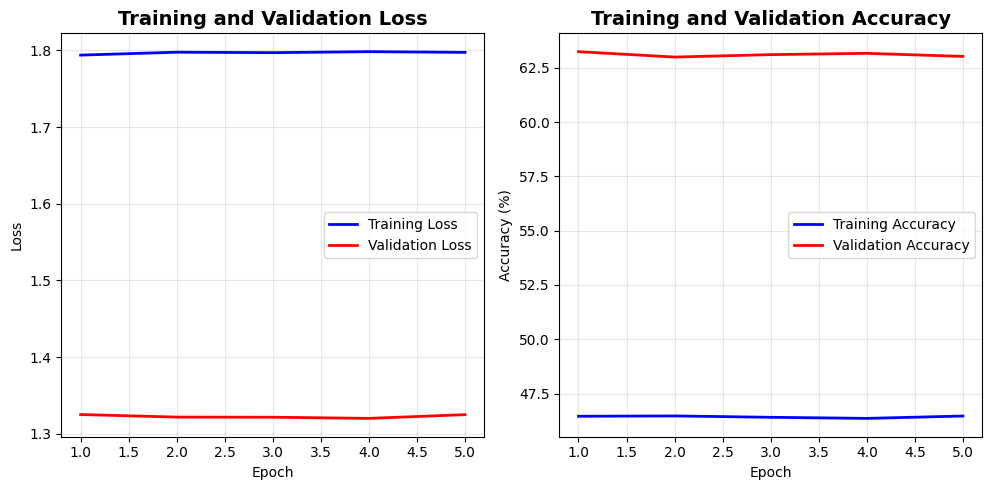

In [ ]:
print("\nGenerating training plots...")

# Get actual number of epochs completed (due to possible early stopping)
actual_epochs = len(train_losses)

# Create training curves
plt.figure(figsize=(15, 5))

# Loss plot
plt.subplot(1, 3, 1)
plt.plot(range(1, actual_epochs + 1), train_losses, 'b-', label='Training Loss', linewidth=2)
plt.plot(range(1, actual_epochs + 1), val_losses, 'r-', label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy plot
plt.subplot(1, 3, 2)
plt.plot(range(1, actual_epochs + 1), train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(range(1, actual_epochs + 1), val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# Learning rate plot (need to track this during training)
# plt.subplot(1, 3, 3)
# if 'lr_history' in globals():  # If you tracked learning rates
#     plt.plot(range(1, actual_epochs + 1), lr_history[:actual_epochs], 'g-', linewidth=2)
# else:  # Fallback to showing the scheduled LR pattern
#     scheduled_lr = [optimizer.param_groups[0]['lr'] * actual_epochs
#     for i in range(actual_epochs):
#         if (i+1) % 10 == 0:  # StepLR with step_size=10
#             scheduled_lr[i:] = [scheduled_lr[i] * 0.1] * (actual_epochs - i)
#     plt.plot(range(1, actual_epochs + 1), scheduled_lr, 'g-', linewidth=2)
# plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
# plt.xlabel('Epoch')
# plt.ylabel('Learning Rate')
# plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save to Google Drive
# plot_path = os.path.join(drive_model_dir, "training_curves.png")
# plt.savefig(plot_path, dpi=300, bbox_inches='tight')
# print(f"Plots saved to {plot_path}")
# plt.show()